In [18]:
import json

import gc_utils
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import cluster as cl

import halo_analysis as halo
import utilities as ut
import gizmo_analysis as gizmo

In [ ]:
sim = "m12f"
# sim_dir = "/Users/z5114326/Documents/simulations/"
sim_dir = "/Volumes/Expansion/simulations/"
fire_dir = sim_dir + sim + "/" + sim + "_res7100"

snap_file = fire_dir + "/snapshot_times.txt"
snap_data = pd.read_table(snap_file, comment="#", header=None, sep=r"\s+")
snap_data.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]

snap_pub_file = sim_dir + "/snapshot_times_public.txt"
snap_pub = pd.read_table(snap_pub_file, comment="#", header=None, sep=r"\s+")
snap_pub.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]

In [20]:
snap_lim = 30

sim_lst = ["m12b", "m12c", "m12f", "m12i", "m12m"]

sim_dict = {sim: {"num_mergers": [], "mass": []} for sim in sim_lst}

In [21]:
proc_file = sim_dir + sim + "/" + sim + "_processed.hdf5"
proc_data = h5py.File(proc_file, "r")  # open processed data file

(array([27., 55., 69., 82., 17.,  2., 18.,  0.,  0.,  5.]),
 array([0.64497419, 1.236763  , 1.82855181, 2.42034062, 3.01212943,
        3.60391824, 4.19570705, 4.78749586, 5.37928468, 5.97107349,
        6.5628623 ]),
 <BarContainer object of 10 artists>)

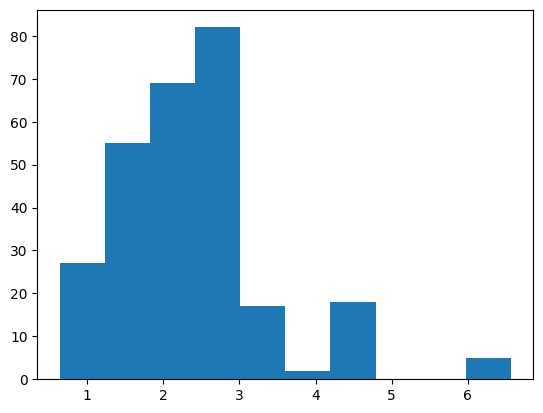

In [22]:
surv_lst = proc_data["it000"]["snapshots"]["snap600"]["gc_id"][()]

src_dat = proc_data["it000"]["source"]
ana_msk = src_dat["analyse_flag"][()] == 1
gc_lst = src_dat["gc_id"]

msk = np.isin(gc_lst, surv_lst)

plt.hist(src_dat["form_time"][ana_msk & msk])